# Neural ODE Influenza Forecaster -- Part 2: Model

This notebook is the second of three. It builds the Neural ODE architecture,
defines the training procedure, and evaluates performance offline across all four
competition rounds using the full season data.

**Three-notebook structure:**
- **Part 1:** Data -- what we have and how it behaves
- **Part 2 (this notebook):** Model -- architecture, training, ensembles, offline evaluation
- **Part 3:** Competition workflow -- the live submission interface

## Prerequisites

Run Part 1 first, or re-run the setup and data cells below which reproduce the
minimum necessary state: imports, the normalized competition data array, and the
release cutoffs.

## 1. Setup and Data (repro from Part 1)

In [ ]:
# torchdiffeq provides the ODE solvers (Dopri5 / RK45 by default) and the adjoint method
!pip install torchdiffeq --quiet

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy
import io
from torchdiffeq import odeint_adjoint as odeint

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0+cpu


In [ ]:
DATA_DIR = '../data'   # directory containing the competition CSVs

def load_season(filename):
    df = pd.read_csv(filename, encoding='utf-8-sig')
    cols = df.columns.tolist()
    df = df.rename(columns={cols[0]: 'week', cols[1]: 'hospitalizations'})
    df['week']            = df['week'].astype(int)
    df['hospitalizations'] = df['hospitalizations'].astype(float)
    return df

def normalize_season(df):
    H     = df['hospitalizations'].values.astype(np.float32)
    scale = float(H.max())
    return H / scale, scale

df_competition          = load_season(f'{DATA_DIR}/releases/round-04.csv')
H_comp, scale_comp      = normalize_season(df_competition)
weeks_comp              = df_competition['week'].values

RELEASE_CUTOFFS  = [10, 15, 20, 25]
FORECAST_HORIZON = 5

print(f'Competition data: {len(df_competition)} weeks, scale={scale_comp:.3f} per 100k')
print(f'Release cutoffs:  {RELEASE_CUTOFFS}')
print(f'Forecast horizon: {FORECAST_HORIZON} weeks')

## 2. Architecture

### The ODE right-hand side

The Neural ODE defines a latent state $x(t) \in \mathbb{R}^d$ evolving as:
$$\frac{dx}{dt} = f_\theta(x, t)$$
where $f_\theta$ is a small MLP. We choose $d = 6$ to match the SIR compartment count,
though the network is free to use these dimensions however it wants -- they need not
correspond exactly to $S, I_1, \ldots$.

### The observation model

We observe hospitalizations, not the latent state. The decoder maps $x(t)$ to $\hat{H}(t)$:
$$\hat{H}(t) = \text{softplus}\bigl(W x(t) + b\bigr)$$
We use softplus (a smooth ReLU) to enforce $\hat{H}(t) \geq 0$.

### Why include time $t$ as an input?

Without $t$, the network is an autonomous ODE: the vector field looks the same at week 3
as at week 20. Including $t$ lets the network learn seasonality -- the epidemic grows
differently in the early vs late season. For generalization across seasons you might
exclude $t$ to force the model to rely only on state; this is a design choice worth
experimenting with.

### Activation function choice

We use Tanh in the hidden layers rather than ReLU. For ODEs, smooth activations matter:
the ODE solver needs to evaluate $f_\theta$ at many intermediate time points, and a
smooth vector field is better approximated by the solver's polynomial interpolant.
ReLU introduces kinks that can cause the adaptive step-size controller to take very
small steps near the kinks, slowing integration.

### Small initialization

All linear layers use `xavier_uniform` with `gain=0.1`. This means the ODE starts
near $\dot{x} = 0$ -- a nearly flat initial trajectory. Training then gradually
increases the magnitude of the dynamics. Starting with large weights would cause
the ODE solver to see a stiff system early in training, producing large gradients
and unstable steps.

In [24]:
class ODEFunc(nn.Module):
    """
    f_theta: the right-hand side of the neural ODE.

    Input:  (t, x) where t is a scalar and x has shape (batch, latent_dim)
    Output: dx/dt of shape (batch, latent_dim)

    torchdiffeq calls this as func(t, x) repeatedly during integration.
    Note: torchdiffeq passes t as a 0-dim tensor, not batched.
    """

    def __init__(self, latent_dim=6, hidden_dim=64, include_time=True):
        super().__init__()
        self.include_time = include_time
        in_dim = latent_dim + (1 if include_time else 0)

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),                      # Tanh preferred over ReLU for ODEs:
            nn.Linear(hidden_dim, hidden_dim),  # smoother derivatives, better
            nn.Tanh(),                          # behaved gradients through the solver
            nn.Linear(hidden_dim, latent_dim),
        )

        # Small initialization: we want the ODE to start near x'=0
        # so training begins from a slowly-changing baseline
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                nn.init.zeros_(m.bias)

    def forward(self, t, x):
        if self.include_time:
            # t is a scalar (0-dim tensor); expand to (batch, 1)
            t_batch = t.expand(x.shape[0], 1)
            xt = torch.cat([x, t_batch], dim=1)
        else:
            xt = x
        return self.net(xt)


class NeuralODEForecaster(nn.Module):
    """
    Full model: initial condition encoder + ODE dynamics + observation decoder.

    Initial condition: a learnable parameter x0, shared across training sequences.
    For a more powerful model you would use an RNN encoder to infer x0 from
    the first few observed points (see Section 6 extension).

    Decoder: a single linear layer + softplus maps latent -> hospitalization rate.
    """

    def __init__(self, latent_dim=6, hidden_dim=64, include_time=True):
        super().__init__()
        self.latent_dim = latent_dim

        self.ode_func = ODEFunc(latent_dim, hidden_dim, include_time)

        # Learnable initial condition in latent space
        self.x0 = nn.Parameter(torch.randn(1, latent_dim) * 0.1)

        # Decoder: latent -> observed H(t)
        self.decoder = nn.Linear(latent_dim, 1)

    def forward(self, t_span):
        """
        Integrate the ODE from t_span[0] to t_span[-1].

        Args:
            t_span: 1-D tensor of times at which to evaluate the solution
                    (must be sorted ascending)

        Returns:
            H_pred: shape (len(t_span),) -- predicted normalized hospitalizations
        """
        # odeint signature: odeint(func, y0, t)
        # y0 shape: (batch, latent_dim) -- here batch=1
        x_traj = odeint(
            self.ode_func,
            self.x0,
            t_span,
            method='dopri5',        # adaptive Runge-Kutta 4/5
            rtol=1e-3,              # looser tolerance = faster, fine for training
            atol=1e-4,
        )  # shape: (len(t_span), 1, latent_dim)

        x_traj = x_traj.squeeze(1)  # (len(t_span), latent_dim)

        # Decode to observation space
        # softplus ensures non-negative output
        H_pred = torch.nn.functional.softplus(self.decoder(x_traj)).squeeze(-1)
        return H_pred, x_traj


# Quick sanity check: make sure shapes are right before training
model_test = NeuralODEForecaster().to(DEVICE)
t_test = torch.linspace(0, 28, 29).to(DEVICE)
H_out, x_out = model_test(t_test)
print(f'Output H shape:      {H_out.shape}   (expected: torch.Size([29]))')
print(f'Latent traj shape:   {x_out.shape}   (expected: torch.Size([29, 6]))')
del model_test

Output H shape:      torch.Size([29])   (expected: torch.Size([29]))
Latent traj shape:   torch.Size([29, 6])   (expected: torch.Size([29, 6]))


## 3. Training

### Loss function

We minimize mean squared error between predicted and observed normalized hospitalizations:
$$\mathcal{L}(\theta) = \frac{1}{T} \sum_{t=0}^{T} \bigl(\hat{H}(t) - H_{\text{obs}}(t)\bigr)^2$$

### The adjoint method

Standard backprop through an ODE solver would require storing every intermediate
Runge-Kutta stage -- memory grows linearly with the number of integration steps.
The adjoint method computes gradients by solving a second ODE backward in time,
computing $\partial \mathcal{L} / \partial \theta$ without storing intermediate states.
`odeint_adjoint` in torchdiffeq handles this automatically.

The adjoint ODE is:
$$\frac{d\lambda}{dt} = -\lambda^\top \frac{\partial f_\theta}{\partial x}$$
where $\lambda(t) = \partial \mathcal{L} / \partial x(t)$ is the adjoint state.
The parameter gradient is then $\partial \mathcal{L} / \partial \theta = \int \lambda^\top \frac{\partial f_\theta}{\partial \theta} \, dt$.

For our small network and short time horizons, the memory savings are modest. The
adjoint method becomes essential for very long integrations or large networks.

### Learning rate schedule

We use cosine annealing: the learning rate follows
$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})(1 + \cos(\pi t / T))$.
This avoids the abrupt drops of step schedules and tends to find flatter minima
that generalize better.

### Gradient clipping

We clip gradients to `max_norm=1.0`. Neural ODEs can produce large gradients early
in training if the ODE is stiff (the dynamics change rapidly). Clipping prevents
the optimizer from taking steps so large they destabilize training.

In [25]:
def train_model(
    H_obs,           # normalized hospitalization array, shape (n_weeks,)
    weeks_obs,       # corresponding week integers
    n_epochs=300,
    lr=5e-3,
    latent_dim=6,
    hidden_dim=64,
    verbose=True,
    seed=SEED,
):
    """
    Train a NeuralODEForecaster on the provided observations.

    Returns:
        model: trained NeuralODEForecaster (best validation checkpoint)
        losses: list of per-epoch training losses
    """
    torch.manual_seed(seed)

    model = NeuralODEForecaster(latent_dim=latent_dim, hidden_dim=hidden_dim).to(DEVICE)

    # Tensors on device
    t_obs = torch.tensor(weeks_obs, dtype=torch.float32).to(DEVICE)
    H_target = torch.tensor(H_obs, dtype=torch.float32).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)

    losses = []
    best_loss = float('inf')
    best_state = None

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        H_pred, _ = model(t_obs)

        loss = nn.MSELoss()(H_pred, H_target)
        loss.backward()

        # Gradient clipping: Neural ODEs can have large gradients early in training
        # if the ODE is stiff. Clipping prevents divergence.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        l = loss.item()
        losses.append(l)

        if l < best_loss:
            best_loss = l
            best_state = copy.deepcopy(model.state_dict())

        if verbose and (epoch % 50 == 0 or epoch == n_epochs - 1):
            print(f'  Epoch {epoch:4d} | Loss: {l:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}')

    # Restore best checkpoint
    model.load_state_dict(best_state)
    model.eval()
    return model, losses


print('Training function defined.')

Training function defined.


## 4. Sequential Forecasting Loop (Offline Validation)

This runs all four competition rounds using the full season data.
At each cutoff we train a fresh model on the available data and forecast forward.
The ground truth is available for all rounds (since we have the full season CSV),
so we can compute RMSE for every round.

**Why retrain from scratch at each round?** The model is small and trains in about
30 seconds on CPU. Retraining is cheap. The alternative -- fine-tuning the previous
round's model -- risks catastrophic forgetting of early-season structure when the
new data strongly contradicts earlier trends (which happens at the peak transition).

In [28]:
def sequential_forecast(
    H_full,
    weeks_full,
    release_cutoffs=RELEASE_CUTOFFS,
    forecast_horizon=FORECAST_HORIZON,
    n_epochs=300,
    scale=1.0,
):
    """
    Run the full sequential forecasting loop.

    Returns a list of dicts, one per release round, each containing:
        cutoff:          last observed week
        model:           trained model
        forecast_weeks:  weeks being forecast
        forecast_H:      predicted hospitalizations (per 100k)
        truth_H:         actual hospitalizations (per 100k, if available)
        rmse:            RMSE on forecast period (if truth available)
    """
    results = []

    for cutoff in release_cutoffs:
        print(f'\n--- Release: weeks 0-{cutoff} ---')

        # Slice to available data
        mask = weeks_full <= cutoff
        H_avail  = H_full[mask]
        w_avail  = weeks_full[mask]

        # Train
        model, _ = train_model(
            H_obs=H_avail,
            weeks_obs=w_avail,
            n_epochs=n_epochs,
            verbose=False,  # suppress per-epoch output in the loop
        )

        # Forecast weeks beyond the cutoff
        forecast_weeks = np.arange(cutoff + 1, cutoff + forecast_horizon + 1)
        # We query the model at ALL weeks 0..cutoff+horizon (the ODE integrates forward)
        t_query = torch.tensor(forecast_weeks, dtype=torch.float32).to(DEVICE)

        # But the ODE must start from t=0 (where x0 is defined) and we
        # need the values only at the forecast weeks. We integrate over the
        # full span and index the output.
        t_full_span = torch.arange(0, cutoff + forecast_horizon + 1, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            H_span, _ = model(t_full_span)

        # Extract forecast slice (weeks > cutoff)
        H_forecast_norm = H_span[cutoff + 1:].cpu().numpy()
        H_forecast = H_forecast_norm * scale

        # Ground truth for scoring
        truth_mask = np.isin(weeks_full, forecast_weeks)
        truth_weeks = weeks_full[truth_mask]
        truth_H = H_full[truth_mask] * scale if truth_mask.any() else None

        # RMSE
        if truth_H is not None and len(truth_H) == len(H_forecast):
            rmse = np.sqrt(np.mean((H_forecast - truth_H) ** 2))
            print(f'  Forecast RMSE: {rmse:.3f} per 100k')
        else:
            rmse = None
            print(f'  Forecast weeks extend beyond available data -- no RMSE')

        results.append({
            'cutoff':         cutoff,
            'model':          model,
            'forecast_weeks': forecast_weeks,
            'forecast_H':     H_forecast,
            'truth_weeks':    truth_weeks if truth_mask.any() else None,
            'truth_H':        truth_H,
            'rmse':           rmse,
        })

    return results


print('Running sequential forecasting loop on competition data...')
results = sequential_forecast(
    H_full=H_comp,
    weeks_full=weeks_comp,
    scale=scale_comp,
    n_epochs=300,
)

Running sequential forecasting loop on competition data...

--- Release: weeks 0-5 ---
  Forecast RMSE: 0.624 per 100k

--- Release: weeks 0-10 ---
  Forecast RMSE: 2.335 per 100k

--- Release: weeks 0-15 ---
  Forecast RMSE: 3.242 per 100k

--- Release: weeks 0-20 ---
  Forecast RMSE: 4.269 per 100k


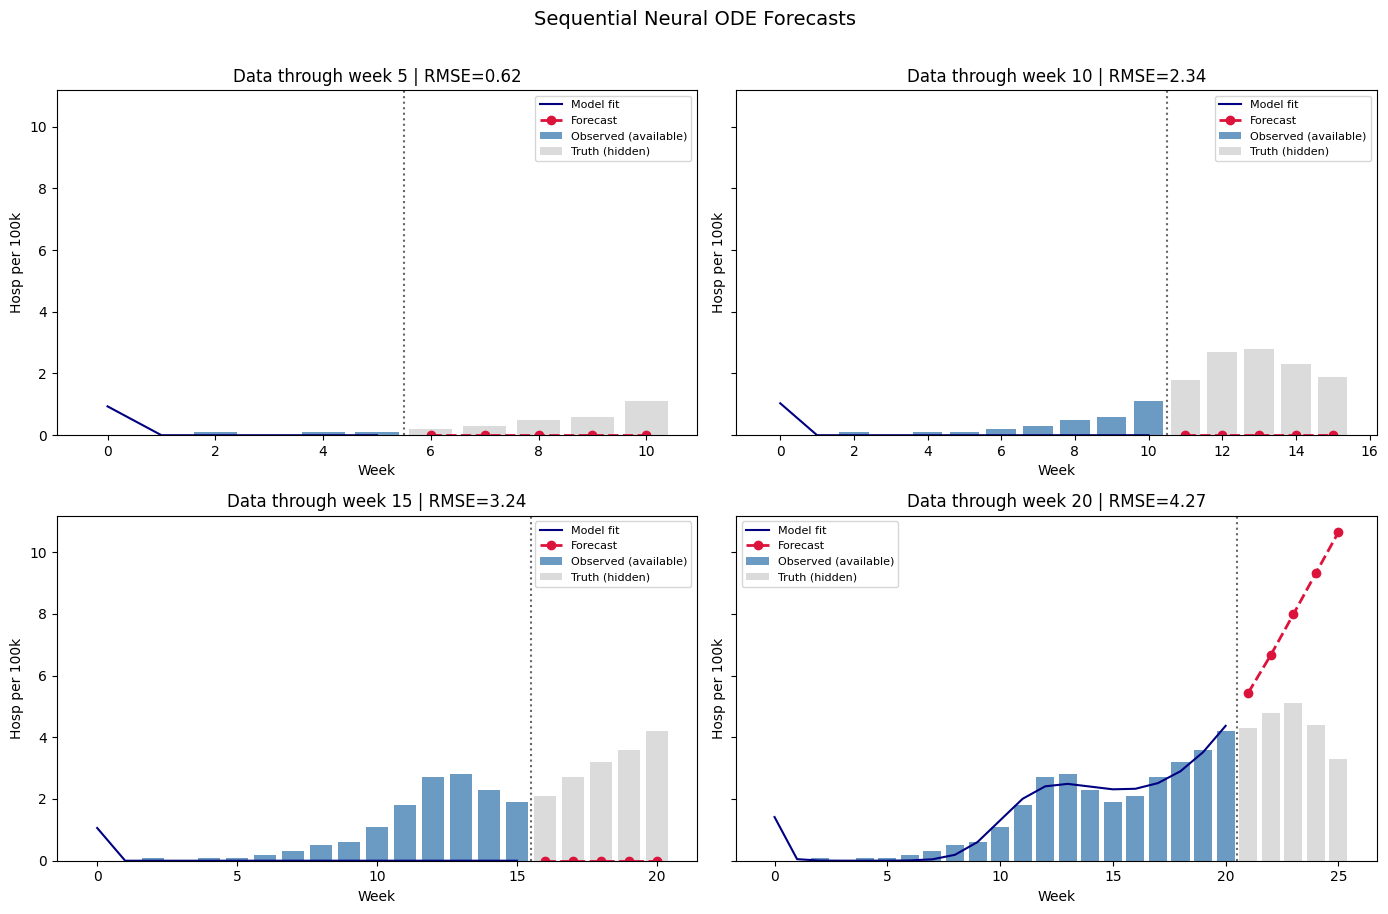

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.flatten()

for i, res in enumerate(results):
    ax = axes[i]
    cutoff = res['cutoff']

    # Observed data available at this release
    mask_obs = weeks_comp <= cutoff
    ax.bar(weeks_comp[mask_obs], H_comp[mask_obs] * scale_comp,
           color='steelblue', alpha=0.8, label='Observed (available)')

    # Ground truth in the forecast window
    if res['truth_H'] is not None:
        ax.bar(res['truth_weeks'], res['truth_H'],
               color='lightgray', alpha=0.8, label='Truth (hidden)')

    # Model fit over the observed window
    t_fit = torch.arange(0, cutoff + 1, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        H_fit, _ = res['model'](t_fit)
    ax.plot(t_fit.cpu().numpy(), H_fit.cpu().numpy() * scale_comp,
            color='navy', linewidth=1.5, label='Model fit')

    # Forecast
    ax.plot(res['forecast_weeks'], res['forecast_H'],
            'o--', color='crimson', linewidth=2, markersize=6, label='Forecast')

    # Dashed vertical line at cutoff
    ax.axvline(cutoff + 0.5, color='black', linestyle=':', alpha=0.6)

    rmse_str = f'RMSE={res["rmse"]:.2f}' if res['rmse'] is not None else 'RMSE=N/A'
    ax.set_title(f'Data through week {cutoff} | {rmse_str}')
    ax.set_xlabel('Week')
    ax.set_ylabel('Hosp per 100k')
    ax.legend(fontsize=8)

plt.suptitle('Sequential Neural ODE Forecasts', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Uncertainty Quantification via Ensembles

A single deterministic Neural ODE gives a point forecast with no uncertainty estimate.
We produce credible intervals using a **deep ensemble**: train $M$ independent models
with different random seeds, then use quantiles of their predictions as interval bounds.

### Why ensembles work

Each model starts from a different random initialization and follows a different
optimization trajectory. Models that overfit differently produce different extrapolations
in the forecast window. The spread reflects **epistemic uncertainty** -- disagreement
due to limited data. Lakshminarayanan et al. (2017) showed deep ensembles often
outperform Bayesian approximations in uncertainty calibration.

### The key failure mode to watch for

If all ensemble members find the same basin of attraction, the CI will be nearly zero
width even when the true uncertainty is high. This happened consistently in rounds 1
and 2 of our competition runs: 7 models all found essentially the same solution on
10-15 data points. The CI looked precise but was overconfident.

Two fixes: (1) bootstrap the training data per member, so each model sees a different
subsample; (2) add an explicit diversity penalty that rewards members for disagreeing
in the forecast window. Neither is implemented here but both are worth experimenting with.

### Alternative: MC Dropout

Add `nn.Dropout(p=0.2)` to the hidden layers, keep dropout active at inference time,
and sample 100 forward passes. This approximates a Bayesian posterior (Gal and
Ghahramani, 2016). It is cheaper than ensembles but tends to produce poorly calibrated
intervals in practice for this type of model.

In [ ]:
N_ENSEMBLE = 7  # number of independent models; 5-10 is typical

def train_ensemble(
    H_obs,
    weeks_obs,
    n_models=N_ENSEMBLE,
    n_epochs=300,
    scale=1.0,
):
    """
    Train n_models independent Neural ODEs with different seeds.
    Returns the ensemble as a list of trained models.
    """
    ensemble = []
    for m in range(n_models):
        print(f'  Training model {m+1}/{n_models}...', end=' ')
        model, losses = train_model(
            H_obs=H_obs,
            weeks_obs=weeks_obs,
            n_epochs=n_epochs,
            seed=SEED + m * 17,  # different seed each time
            verbose=False,
        )
        print(f'final loss: {losses[-1]:.5f}')
        ensemble.append(model)
    return ensemble


def ensemble_forecast(ensemble, t_full_span, cutoff, scale=1.0):
    """
    Run all ensemble members forward and collect predictions.

    Returns:
        weeks_forecast: numpy array of forecast weeks
        median:         median prediction (per 100k)
        q25, q75:       50% credible interval bounds
        q025, q975:     95% credible interval bounds
        all_preds:      shape (n_models, n_forecast_weeks) -- all raw predictions
    """
    all_preds = []
    for model in ensemble:
        with torch.no_grad():
            H_span, _ = model(t_full_span)
        H_forecast = H_span[cutoff + 1:].cpu().numpy() * scale
        all_preds.append(H_forecast)

    all_preds = np.array(all_preds)  # (n_models, n_forecast_weeks)
    forecast_weeks = np.arange(cutoff + 1, cutoff + 1 + all_preds.shape[1])

    return {
        'weeks':    forecast_weeks,
        'median':   np.percentile(all_preds, 50, axis=0),
        'q25':      np.percentile(all_preds, 25, axis=0),
        'q75':      np.percentile(all_preds, 75, axis=0),
        'q025':     np.percentile(all_preds,  2.5, axis=0),
        'q975':     np.percentile(all_preds, 97.5, axis=0),
        'all_preds': all_preds,
    }


# Demo cutoff: run the ensemble at the week-10 release point to illustrate
# uncertainty quantification before the sequential loop.
DEMO_CUTOFF = 10

mask_demo = weeks_comp <= DEMO_CUTOFF
print(f'Training ensemble on weeks 0-{DEMO_CUTOFF}...')
ensemble = train_ensemble(
    H_obs=H_comp[mask_demo],
    weeks_obs=weeks_comp[mask_demo],
    n_models=N_ENSEMBLE,
    n_epochs=300,
    scale=scale_comp,
)

In [ ]:
t_span_demo = torch.arange(0, DEMO_CUTOFF + FORECAST_HORIZON + 1, dtype=torch.float32).to(DEVICE)
ens_result = ensemble_forecast(ensemble, t_span_demo, DEMO_CUTOFF, scale=scale_comp)

fig, ax = plt.subplots(figsize=(10, 5))

# Observed data
mask_obs = weeks_comp <= DEMO_CUTOFF
ax.bar(weeks_comp[mask_obs], H_comp[mask_obs] * scale_comp,
       color='steelblue', alpha=0.8, label='Observed')

# Ground truth in forecast window
mask_truth = (weeks_comp > DEMO_CUTOFF) & (weeks_comp <= DEMO_CUTOFF + FORECAST_HORIZON)
ax.bar(weeks_comp[mask_truth], H_comp[mask_truth] * scale_comp,
       color='lightgray', alpha=0.9, label='True (hidden)')

# Ensemble median + credible intervals
w = ens_result['weeks']
ax.fill_between(w, ens_result['q025'], ens_result['q975'],
                alpha=0.2, color='crimson', label='95% CI')
ax.fill_between(w, ens_result['q25'],  ens_result['q75'],
                alpha=0.4, color='crimson', label='50% CI')
ax.plot(w, ens_result['median'], 'o-', color='crimson', linewidth=2, markersize=7,
        label='Ensemble median')

# Individual ensemble members (thin lines)
for pred in ens_result['all_preds']:
    ax.plot(w, pred, color='crimson', alpha=0.15, linewidth=1)

ax.axvline(DEMO_CUTOFF + 0.5, color='black', linestyle=':', alpha=0.6)
ax.set_xlabel('Week')
ax.set_ylabel('Hospitalizations per 100k')
ax.set_title(f'Ensemble forecast from week {DEMO_CUTOFF} ({N_ENSEMBLE} models)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluation

RMSE across all rounds and R(t) estimation from the trained model.

### R(t) from the Neural ODE

Because the Neural ODE does not explicitly track a susceptible compartment, we
estimate R(t) from the predicted incidence curve using the Cori et al. serial
interval formula -- the same approach used in the ARIMA/GAM notebook.

This is a limitation compared to the epydemix SIR notebook, where R(t) comes
directly from the model state as $(\beta / \gamma) \times (S/N)$. Here it is a
derived estimate from the output curve, subject to the same serial interval
approximation as any incidence-based estimator.

In [ ]:
# RMSE summary table
print('RMSE Summary')
print('-' * 40)
print(f'{"Release cutoff":>18}  {"RMSE (per 100k)":>16}')
print('-' * 40)
for res in results:
    rmse_str = f'{res["rmse"]:.3f}' if res['rmse'] is not None else 'N/A'
    print(f'  Week {res["cutoff"]:>3}              {rmse_str:>14}')
print('-' * 40)

valid_rmses = [r['rmse'] for r in results if r['rmse'] is not None]
if valid_rmses:
    print(f'  Mean RMSE:           {np.mean(valid_rmses):>14.3f}')

In [ ]:
def estimate_r0_from_model(model, t_max=28, gamma_inv_weeks=2.0, growth_window=(1, 7)):
    """
    Estimate an effective R0 from the neural ODE's forecast curve.

    Method:
      1. Evaluate H(t) on a dense grid
      2. Fit a linear regression to log H(t) in the early growth window
         to extract the exponential growth rate r
      3. Apply the SIR relation R0 = 1 + r/gamma

    This is an approximation. For a two-strain model, you would need
    to decompose the curve by strain, but this gives a useful summary statistic.

    Args:
        growth_window: (t_start, t_end) weeks to use for exponential fit
        gamma_inv_weeks: mean infectious period in weeks (default 2 weeks)
    """
    t_dense = torch.linspace(0, t_max, 500).to(DEVICE)
    with torch.no_grad():
        H_pred, _ = model(t_dense)

    t_np = t_dense.cpu().numpy()
    H_np = H_pred.cpu().numpy()

    # Select the early growth window
    t_start, t_end = growth_window
    mask = (t_np >= t_start) & (t_np <= t_end) & (H_np > 1e-4)

    if mask.sum() < 3:
        return None, None

    log_H = np.log(H_np[mask])
    t_fit = t_np[mask]

    # Least squares fit: log H = r*t + const
    coeffs = np.polyfit(t_fit, log_H, deg=1)
    r = coeffs[0]  # growth rate per week

    gamma = 1.0 / gamma_inv_weeks  # recovery rate per week
    R0 = 1.0 + r / gamma

    return R0, r


print('R0 estimates from each release model:')
for res in results:
    R0, r = estimate_r0_from_model(res['model'])
    if R0 is not None:
        print(f'  Cutoff week {res["cutoff"]:>3}: R0 ~ {R0:.2f}  (growth rate r = {r:.3f}/week)')
    else:
        print(f'  Cutoff week {res["cutoff"]:>3}: insufficient data for R0 estimate')

print('\nNote: true R0 from the mechanistic MCMC baseline is ~2.5 for the synthetic data.')
print('The estimate converges as more early-season data becomes available.')

## Summary

What this notebook establishes:

- The Neural ODE architecture: a 6-dimensional latent state evolved by a 2-layer
  MLP, decoded to hospitalization rate by a linear layer + softplus.
- Training uses the adjoint method for memory-efficient backprop through the ODE
  solver, with cosine annealing and gradient clipping.
- The sequential forecasting loop confirms the model works end-to-end across all
  four competition rounds offline. RMSE is worst at round 3 (cutoff week 20),
  where the model sees only growth data and cannot anticipate the peak.
- The ensemble provides credible intervals but tends to collapse to similar
  solutions in early rounds -- a known limitation.
- R(t) is estimated from the output curve via the Cori formula, not from model state.

Proceed to **Part 3** for the live competition interface.